In [75]:
from datamodel import OrderDepth, UserId, TradingState, Order
from typing import List, Dict
import string
import numpy as np

In [76]:
# DRYLAND FLAX
# setup data
# df_orders[price] = [bid_vol (buys), ask_vol (sells)]
df_orders: Dict[int, list(int)] = {
    27: [28_000, 0],
    28: [12_000, 40_000],
    29: [5_000, 0],
    30: [30_000, 0],
    31: [0, 20_000],
    32: [0, 20_000],
    33: [0, 30_000]
}


In [77]:
# add in our bid
our_price = 28
our_is_bid = True
our_qty = 40_000

In [78]:


# if our bid is below min price??


def get_vol_traded(guess_price: int, orders: Dict[int, list(int)], user_price: int, user_is_bid: bool, user_qty: int ) -> int:
    bid_qty = 0
    ask_qty = 0
    for price, qtys in orders.items():
        if price >= guess_price:
            bid_qty += qtys[0]
        
        if price <= guess_price:
            ask_qty += qtys[1]

    if user_is_bid and user_price >= guess_price:
        bid_qty += user_qty
    elif (not user_is_bid) and user_price <= guess_price:
        ask_qty += user_qty

    clear_vol = min(bid_qty, ask_qty)

    return clear_vol

def get_clear_price(orders: Dict[int, list(int)], user_price: int, user_is_bid: bool, user_qty: int) -> int:
    min_price = min(orders)
    max_price = max(orders)
    
    max_vol = 0
    clear_price = 0

    for price in range(min_price, max_price+1):
        new_vol = get_vol_traded(price, df_orders, user_price, user_is_bid, user_qty)
        if new_vol >= max_vol:
            max_vol = new_vol
            clear_price = price

    # print(clear_price)
    return clear_price


In [79]:

def calc_pnl(orders: Dict[int, list(int)], user_price: int, user_is_bid: bool, user_qty: int, end_buy_price: int, fee_per_unit: float = 0.0) -> int:
    clear_price = get_clear_price(orders, user_price, user_is_bid, user_qty)
    
    # stale book qtys
    bid_qty = 0
    ask_qty = 0
    for price, qtys in orders.items():
        if price >= clear_price:
            bid_qty += qtys[0]
        
        if price <= clear_price:
            ask_qty += qtys[1]
            
    actual_qty = 0
    margin = 0
    
    # Precompute book at clearing price
    better_bid_qty = sum(qtys[0] for p, qtys in orders.items() if p > clear_price)
    same_bid_qty = sum(qtys[0] for p, qtys in orders.items() if p == clear_price)

    better_ask_qty = sum(qtys[1] for p, qtys in orders.items() if p < clear_price)
    same_ask_qty = sum(qtys[1] for p, qtys in orders.items() if p == clear_price)

    total_supply = better_ask_qty + same_ask_qty
    total_demand = better_bid_qty + same_bid_qty

    if user_is_bid and user_price >= clear_price:
        # ALL demand ahead of you (you are last at your level)
        demand_ahead = better_bid_qty + same_bid_qty

        # what's left after they fill
        remaining_supply = max(0, total_supply - demand_ahead)

        actual_qty = min(user_qty, remaining_supply)
        margin = end_buy_price - clear_price

    elif (not user_is_bid) and user_price <= clear_price:
        # ALL supply ahead of you
        supply_ahead = better_ask_qty + same_ask_qty

        remaining_demand = max(0, total_demand - supply_ahead)

        actual_qty = min(user_qty, remaining_demand)
        margin = clear_price - end_buy_price

    pnl = actual_qty * margin
    pnl -= 2 * actual_qty * fee_per_unit
    return pnl



In [80]:
from matplotlib import pyplot as plt
import math

def plot_all(orders: Dict[int, list(int)], end_buy_price: int, fee_per_unit: float = 0.0):
    min_price = min(orders)
    max_price = max(orders)

    possible_prices = list(range(min_price, max_price + 1))
    possible_is_bid = [True, False]
    possible_qtys = range(0, 40_001, 1000)

    num_plots = len(possible_prices) * len(possible_is_bid)
    cols = 4
    rows = math.ceil(num_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()

    plot_idx = 0

    for is_bid in possible_is_bid:
        side = "BID" if is_bid else "ASK"

        for price in possible_prices:
            pnls = []

            for qty in possible_qtys:
                pnl = calc_pnl(df_orders, price, is_bid, qty, end_buy_price, fee_per_unit)
                pnls.append(pnl)

            ax = axes[plot_idx]
            ax.plot(possible_qtys, pnls)
            ax.set_title(f"{side} @ {price}")
            ax.set_xlabel("Qty")
            ax.set_ylabel("PnL")
            ax.grid()

            plot_idx += 1

    # Hide any unused subplots
    for i in range(plot_idx, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

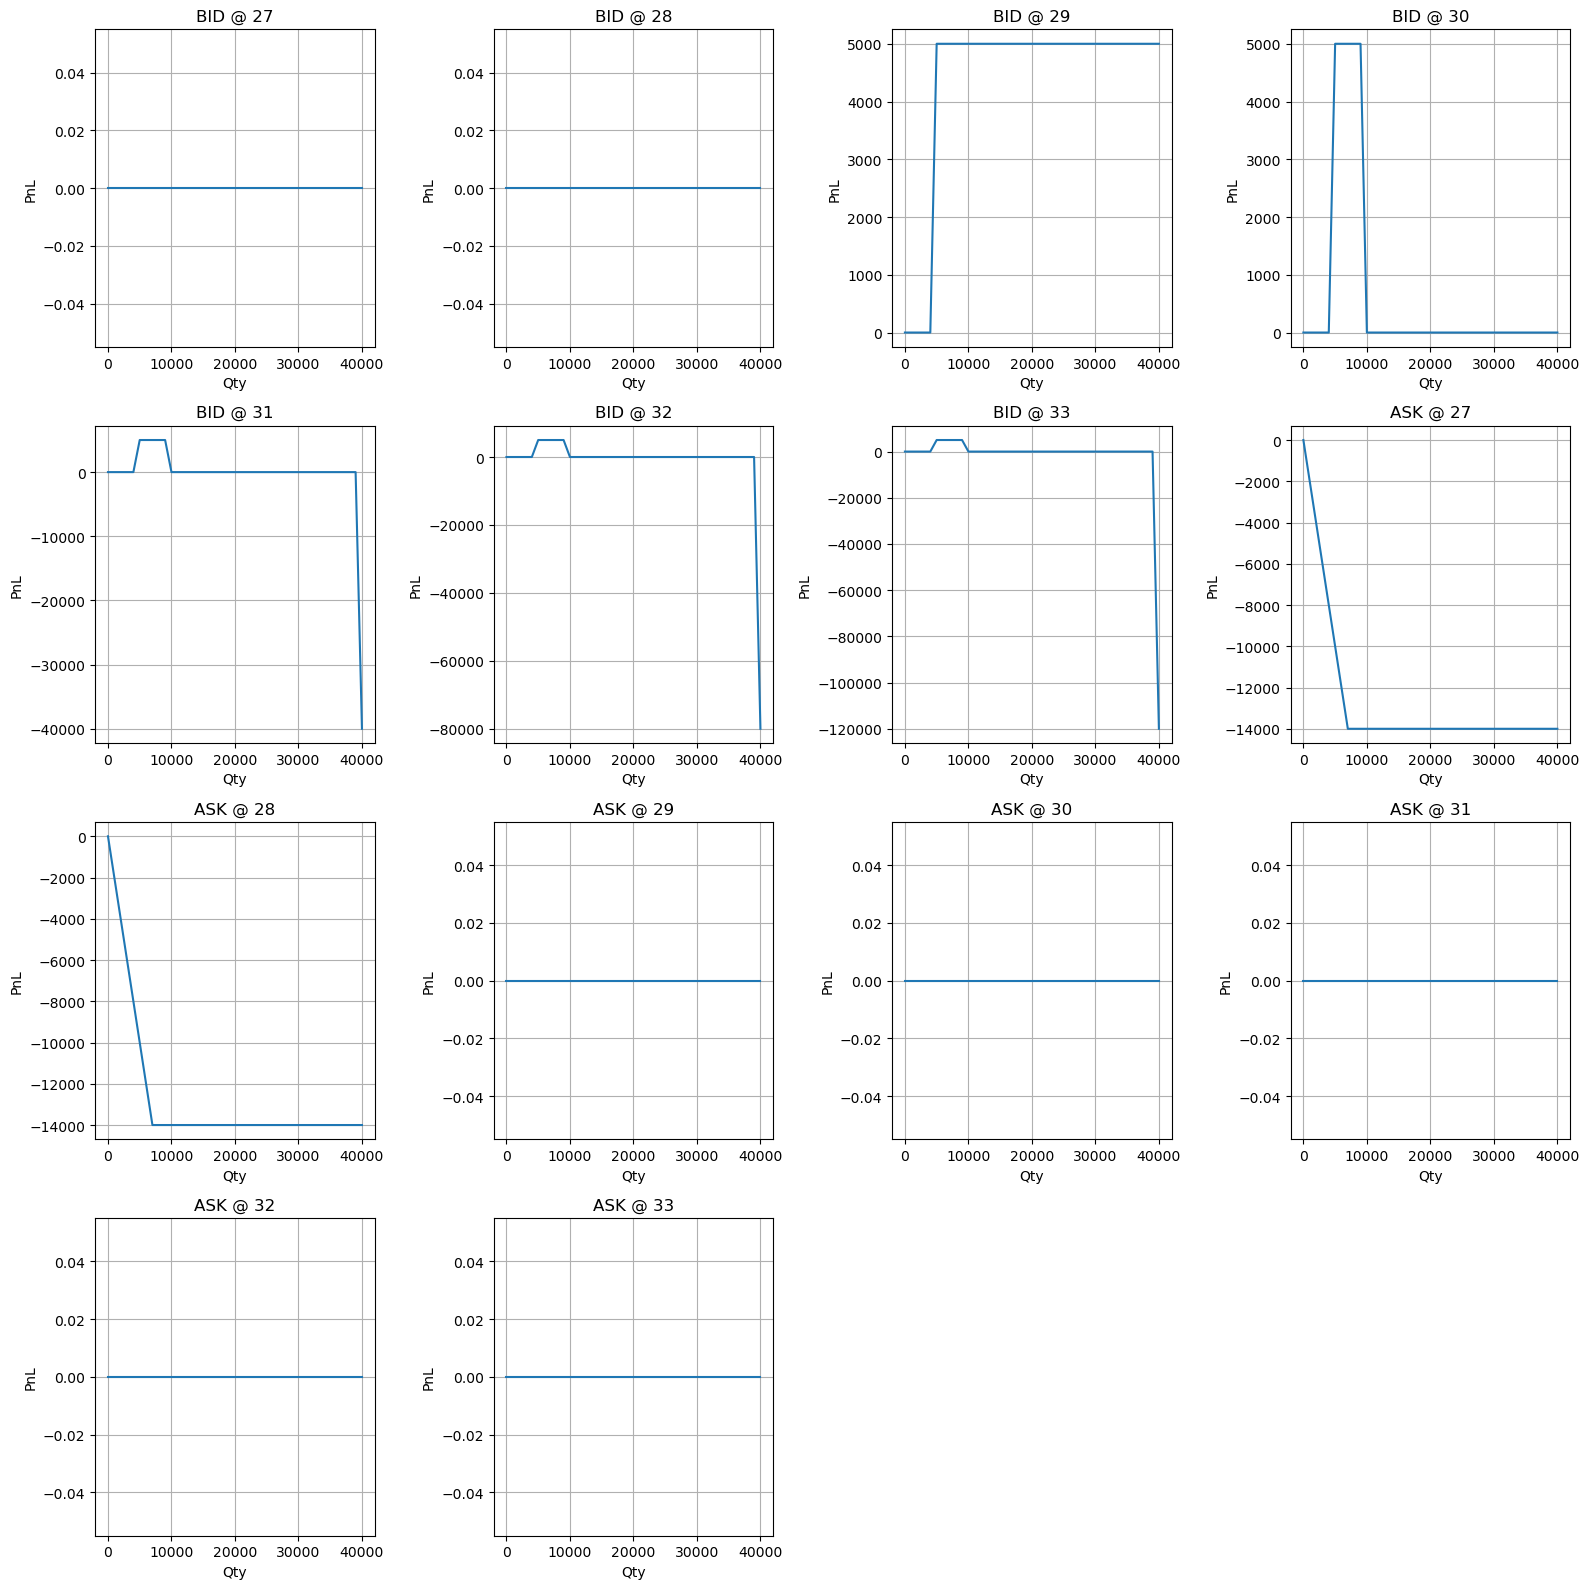

In [81]:
# plot all for dryland flax
plot_all(df_orders, 30)

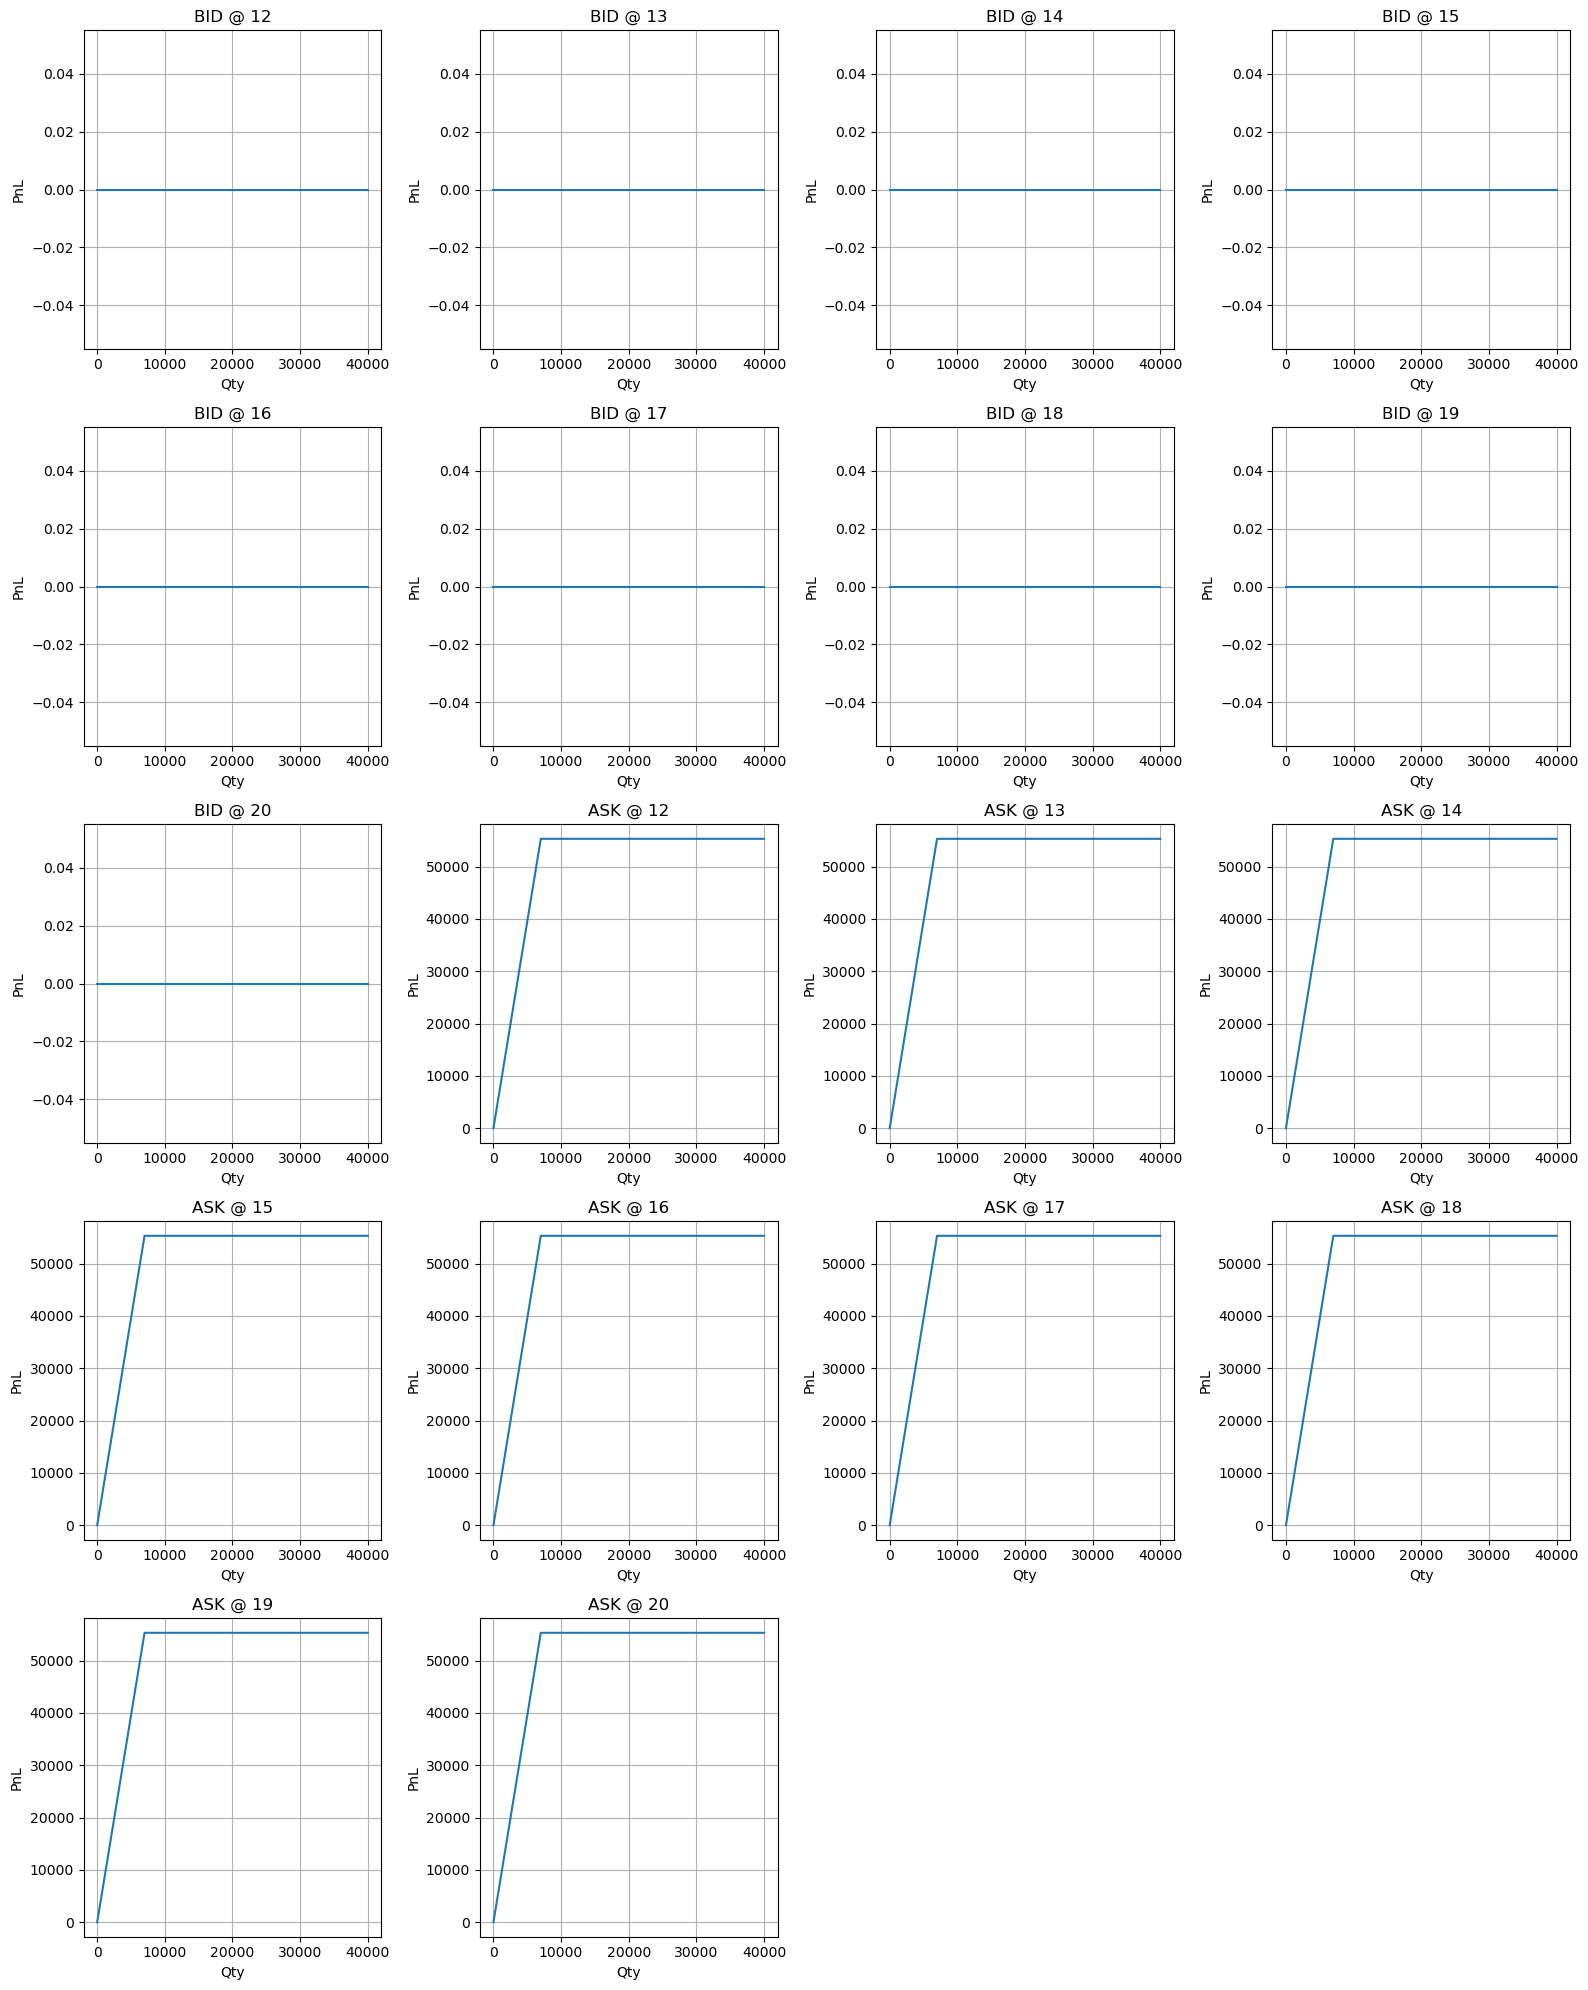

In [82]:
em_orders: Dict[int, list(int)] = {
    12: [0, 20_000],
    13: [7_000, 25_000],
    14: [10_000, 35_000],
    15: [5_000, 6_000],
    16: [10_000, 5_000],
    17: [5_000, 0],
    18: [6_000, 10_000],
    19: [17_000, 12_000],
    20: [43_000, 0]
}

# NOTE: FEE PER UNIT IS PER TRADE, SO IT'S DOUBLED IN CALCS
plot_all(em_orders, 20, 0.05)
